In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("hosseinbadrnezhad/human-faces-dataset-male-female-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'human-faces-dataset-male-female-classification' dataset.
Path to dataset files: /kaggle/input/human-faces-dataset-male-female-classification
Contents of base_path (/kaggle/input):
['human-faces-dataset-male-female-classification']
Contents of path (/kaggle/input/human-faces-dataset-male-female-classification):
['men', 'women']


In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Output path for the split dataset
output_folder = "dataset_split"

# Split the dataset: 80% Train, 20% Val
# If you want 3 parts (Train/Val/Test), change ratio to (.8, .1, .1)
splitfolders.ratio(path, output=output_folder, seed=1337, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Split completed! New data is located at: {output_folder}")

Copying files: 2000 files [00:21, 94.79 files/s] 

Split completed! New data is located at: dataset_split


In [ ]:
import os

def count_files(directory):
    for root, dirs, files in os.walk(directory):
        if not dirs: # Only print leaf directories
            print(f"{root}: {len(files)} images")

print("Verifying image counts after split:")
count_files(output_folder)

Verifying image counts after split:
dataset_split/val/women: 255 images
dataset_split/val/men: 146 images
dataset_split/train/women: 1018 images
dataset_split/train/men: 581 images


In [ ]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("Please install GPU version of TF or check Colab Runtime settings.")

Num GPUs Available:  1
Default GPU Device: /device:GPU:0


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15  # Increased epochs for fine-tuning

# Data Loaders with slightly more augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    'dataset_split/train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    'dataset_split/val',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# Build Model with Fine-tuning
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Unfreeze the last 20 layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Use a much smaller learning rate for fine-tuning
model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

Found 1599 images belonging to 2 classes.
Found 401 images belonging to 2 classes.
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.5178 - loss: 0.9308 - val_accuracy: 0.3641 - val_loss: 0.8977
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.5929 - loss: 0.7688 - val_accuracy: 0.3641 - val_loss: 0.7484
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.6085 - loss: 0.7484 - val_accuracy: 0.3641 - val_loss: 0.7248
Epoch 4/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.6379 - loss: 0.6802 - val_accuracy: 0.3641 - val_loss: 0.7370
Epoch 5/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.6304 - loss: 0.6757 - val_accuracy: 0.3666 - val_loss: 0.7271
Epoch 6/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.6623 - loss: 0.6570 - val_accuracy: 0.3766 - val_loss: 0.7416
Epoch 7/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 80s 2s/step - accuracy: 0.6504 - loss: 0.6608 - val_accuracy: 0.4988 - val_loss: 0.6902
Epoch 8/15
50/50 ━━━━━━━━━━━━━━━━━

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate the model
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

# Detailed Classification Report
val_generator.reset()
predictions = model.predict(val_generator)
predicted_classes = (predictions > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(val_generator.classes, predicted_classes, target_names=val_generator.class_indices.keys()))

13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.7756 - loss: 0.4585
Validation Loss: 0.4585
Validation Accuracy: 0.7756
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step

Classification Report:
              precision    recall  f1-score   support

         men       0.36      0.55      0.43       146
       women       0.63      0.44      0.51       255

    accuracy                           0.48       401
   macro avg       0.49      0.49      0.47       401
weighted avg       0.53      0.48      0.48       401



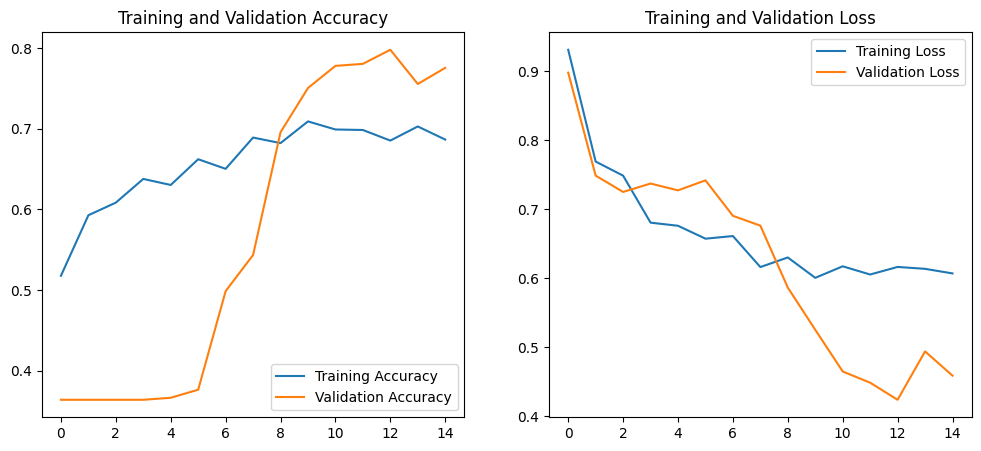

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')

    plt.show()

plot_history(history)